## Exploratory data Analysis

### 1. Data Observation

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("D:\Viki\Guvi DS\Capstone Projects\youtube-monetization\data\youtube_ad_revenue_dataset.csv")

<>:1: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
<>:1: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
C:\Users\Vijay\AppData\Local\Temp\ipykernel_15720\2952992519.py:1: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
  df = pd.read_csv("D:\Viki\Guvi DS\Capstone Projects\youtube-monetization\data\youtube_ad_revenue_dataset.csv")


In [3]:
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [4]:
df.shape

(122400, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [6]:
df.columns

Index(['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd'],
      dtype='object')

In [8]:
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [10]:
df.describe(include='object')

,video_id,date,category,device,country
count,122400,122400,122400,122400,122400
unique,5000,365,6,4,6
top,vid_3033,2025-04-03 10:50:40.993199,Education,TV,CA
freq,47,382,20514,30646,20603


In [11]:
df.groupby('video_id')['subscribers'].nunique().sort_values(ascending=False).head()

video_id
vid_3033    46
vid_1725    42
vid_4483    42
vid_988     41
vid_2666    40
Name: subscribers, dtype: int64

In [12]:
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                   6117
comments                6112
watch_time_minutes      6105
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [18]:
# 1. Fix date
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 2. Check missing again
df.isnull().sum()

# 3. Check duplicates
df.duplicated().sum()

np.int64(2400)

In [23]:
df.value_counts().value_counts()

count
1    100803
2      2076
Name: count, dtype: int64

In [24]:
df = df.drop_duplicates()

In [ ]:
df.shape

# 2400 Duplicated Rows Droped


(120000, 12)

### 2. Target Analysis

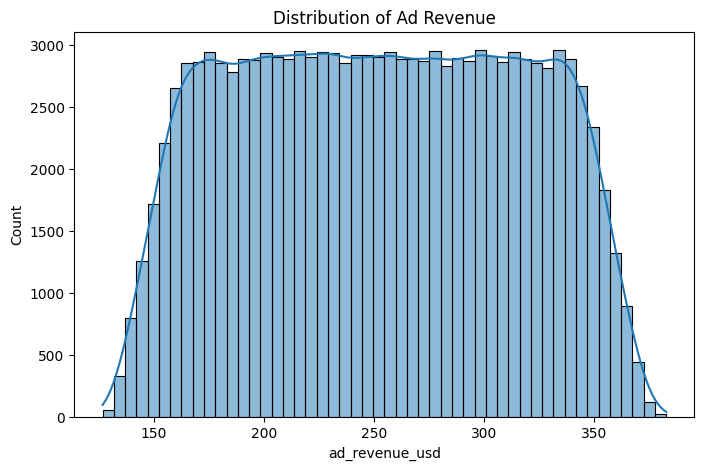

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['ad_revenue_usd'], bins=50, kde=True)
plt.title("Distribution of Ad Revenue")
plt.show()

In [30]:
df['ad_revenue_usd'].describe()

count    120000.000000
mean        252.711361
std          61.954125
min         126.590603
25%         199.892158
50%         252.678607
75%         305.613497
max         382.768254
Name: ad_revenue_usd, dtype: float64

In [32]:
df['ad_revenue_usd'].skew()

np.float64(0.0009478946949712725)

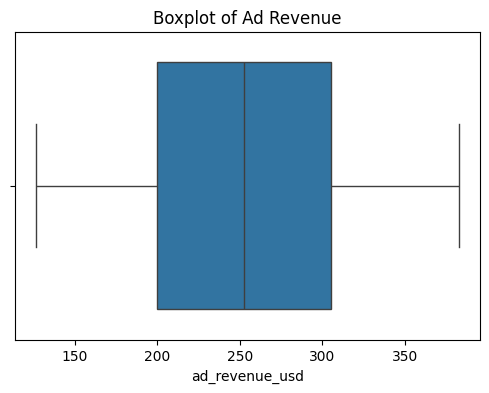

In [33]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['ad_revenue_usd'])
plt.title("Boxplot of Ad Revenue")
plt.show()

### Target Variable Analysis: `ad_revenue_usd`

* **Uniform & Symmetric Distribution**
  Revenue values are evenly spread (~125–380 USD) with no strong concentration.

* **No Skewness**
  Skewness ≈ 0 indicates a perfectly balanced distribution.

* **No Outliers**
  Boxplot shows no extreme values or long tails.

* **No Transformation Needed**
  Since the data is well-behaved, transformations (e.g., log) are unnecessary.

---

### Business Insight

Unlike real-world YouTube data (which is typically skewed with viral spikes), this dataset shows **stable and evenly distributed revenue**, meaning:

* No viral/outlier-driven earnings
* Revenue is consistently distributed across videos

---

## 3. Numerical Feature Analysis

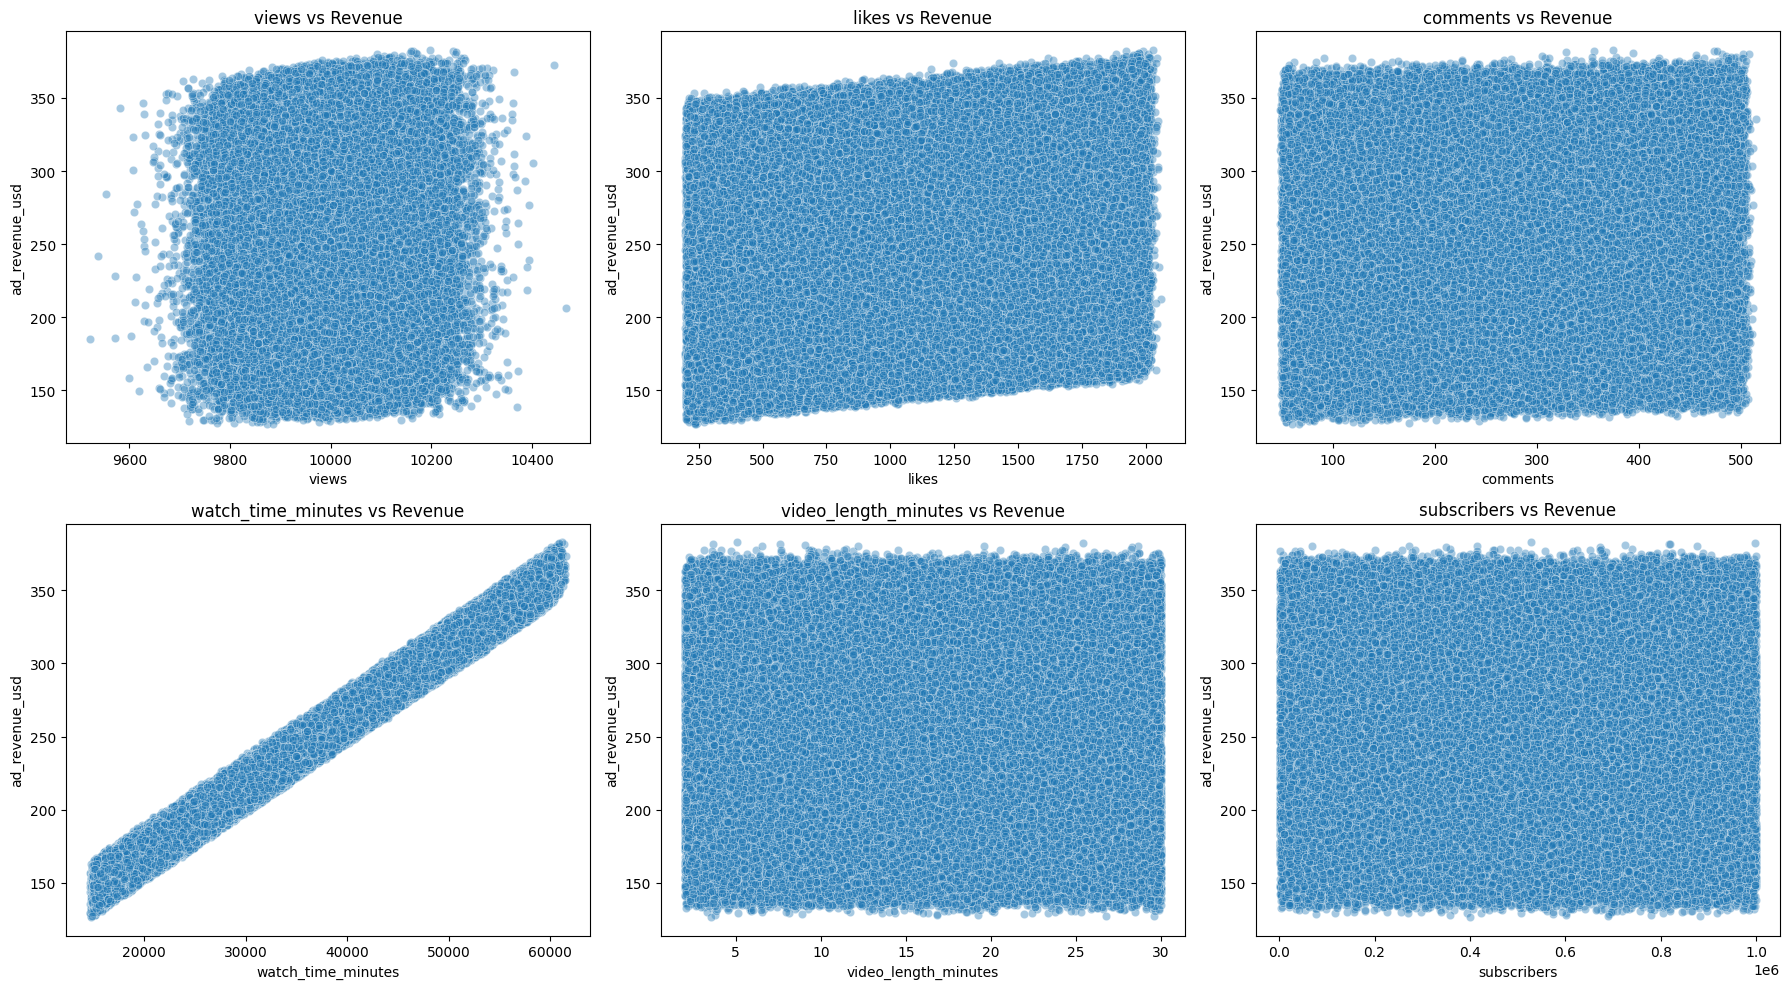

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('ad_revenue_usd')

# grid size
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.scatterplot(x=df[col], y=df['ad_revenue_usd'], alpha=0.4)
    plt.title(f"{col} vs Revenue")

plt.tight_layout()
plt.show()

####  Views vs Ad Revenue

* No visible relationship between views and revenue
* Data points form a random, uniform spread
* **Insight:** Views do not significantly influence revenue in this dataset

---

####  Likes vs Ad Revenue

* Slight positive trend observed, but with high dispersion
* Relationship is weak and inconsistent
* **Insight:** Likes have minimal predictive power due to high variance

---

####  Comments vs Ad Revenue

* No clear trend or pattern observed
* Data appears randomly distributed
* **Insight:** Comments do not contribute meaningfully to revenue prediction

---

####  Watch Time (minutes) vs Ad Revenue

* Strong linear relationship with a clear upward trend
* Data points are tightly clustered along a line
* **Insight:** Watch time is the **most influential and dominant predictor** of revenue

---

####  Video Length (minutes) vs Ad Revenue

* No discernible pattern or trend
* Revenue remains unaffected across different video lengths
* **Insight:** Video length has no significant impact on revenue

---

####  Subscribers vs Ad Revenue

* No visible correlation between subscribers and revenue
* Scatter pattern indicates randomness
* **Insight:** Subscriber count does not directly influence revenue in this dataset

---

###  Overall Conclusion

* **Watch Time** is the only strong driver of revenue
* Other features show weak or no relationship
* Dataset appears structured such that revenue is primarily dependent on watch time


## 4. Correlation Analysis

In [39]:
import pandas as pd

# Select only numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numerical_cols.corr()

# Display correlation with target variable
target_corr = corr_matrix['ad_revenue_usd'].sort_values(ascending=False)

print("Correlation with Target (ad_revenue_usd):\n")
print(target_corr)

Correlation with Target (ad_revenue_usd):

ad_revenue_usd          1.000000
watch_time_minutes      0.988869
likes                   0.146269
views                   0.037942
comments                0.034494
subscribers             0.005065
video_length_minutes    0.000364
Name: ad_revenue_usd, dtype: float64


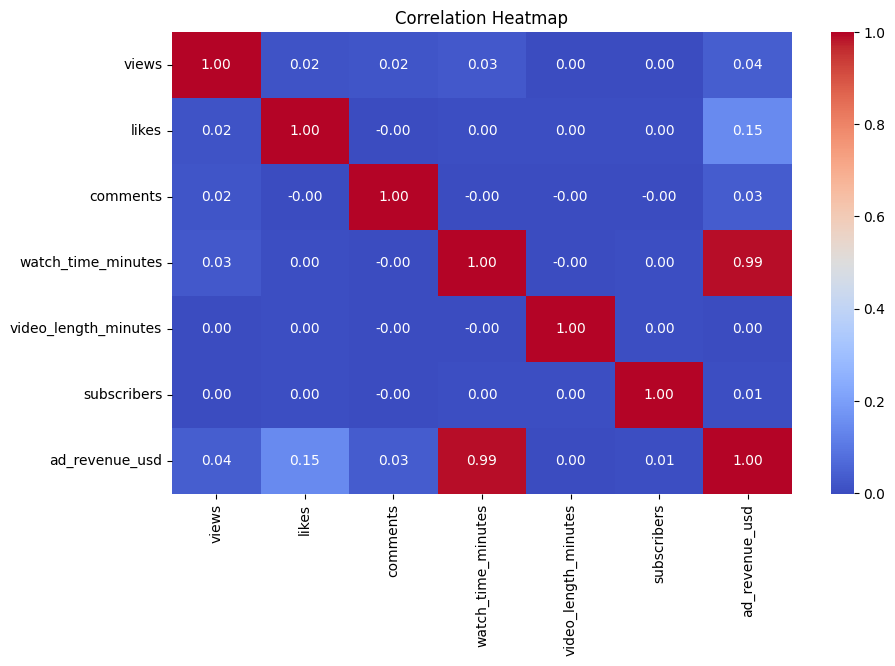

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [41]:
# Set threshold for strong correlation
threshold = 0.3

strong_features = target_corr[abs(target_corr) > threshold]

print("Strong Features (|correlation| > 0.3):\n")
print(strong_features)

Strong Features (|correlation| > 0.3):

ad_revenue_usd        1.000000
watch_time_minutes    0.988869
Name: ad_revenue_usd, dtype: float64


In [42]:
import numpy as np

# Create a mask for upper triangle
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find feature pairs with high correlation
high_corr_pairs = corr_pairs.stack().sort_values(ascending=False)

# Filter strong correlations (excluding target for now)
high_corr_pairs = high_corr_pairs[abs(high_corr_pairs) > 0.7]

print("Highly Correlated Feature Pairs:\n")
print(high_corr_pairs)

Highly Correlated Feature Pairs:

watch_time_minutes  ad_revenue_usd    0.988869
dtype: float64


In [43]:
df[['watch_time_minutes', 'ad_revenue_usd']].head(10)

,watch_time_minutes,ad_revenue_usd
0,26497.214184,203.178237
1,15209.747445,140.880508
2,57332.658498,360.134008
3,31334.517771,224.638261
4,15665.666434,165.514388
5,35131.756228,234.965996
6,35380.070908,255.009412
7,19263.212580,164.533455
8,NaN,336.409856
9,40011.579945,246.711883


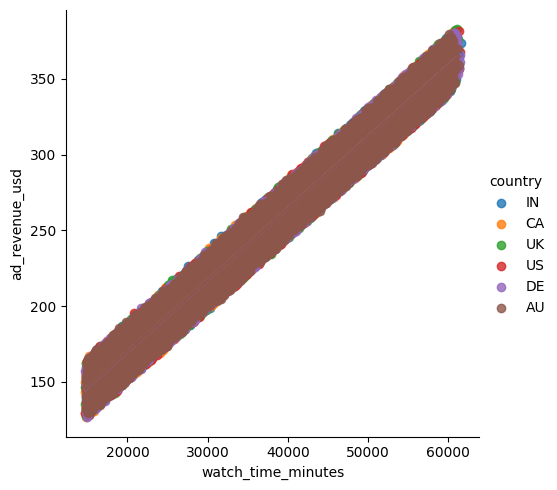

In [ ]:
import seaborn as sns

sns.lmplot(
    data=df,
    x='watch_time_minutes',
    y='ad_revenue_usd',
    hue='country'
)

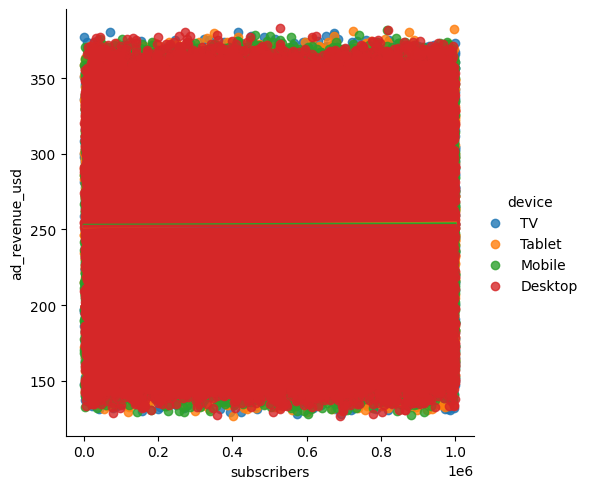

In [47]:
sns.lmplot(
    data=df,
    x='subscribers',
    y='ad_revenue_usd',
    hue='device'
)

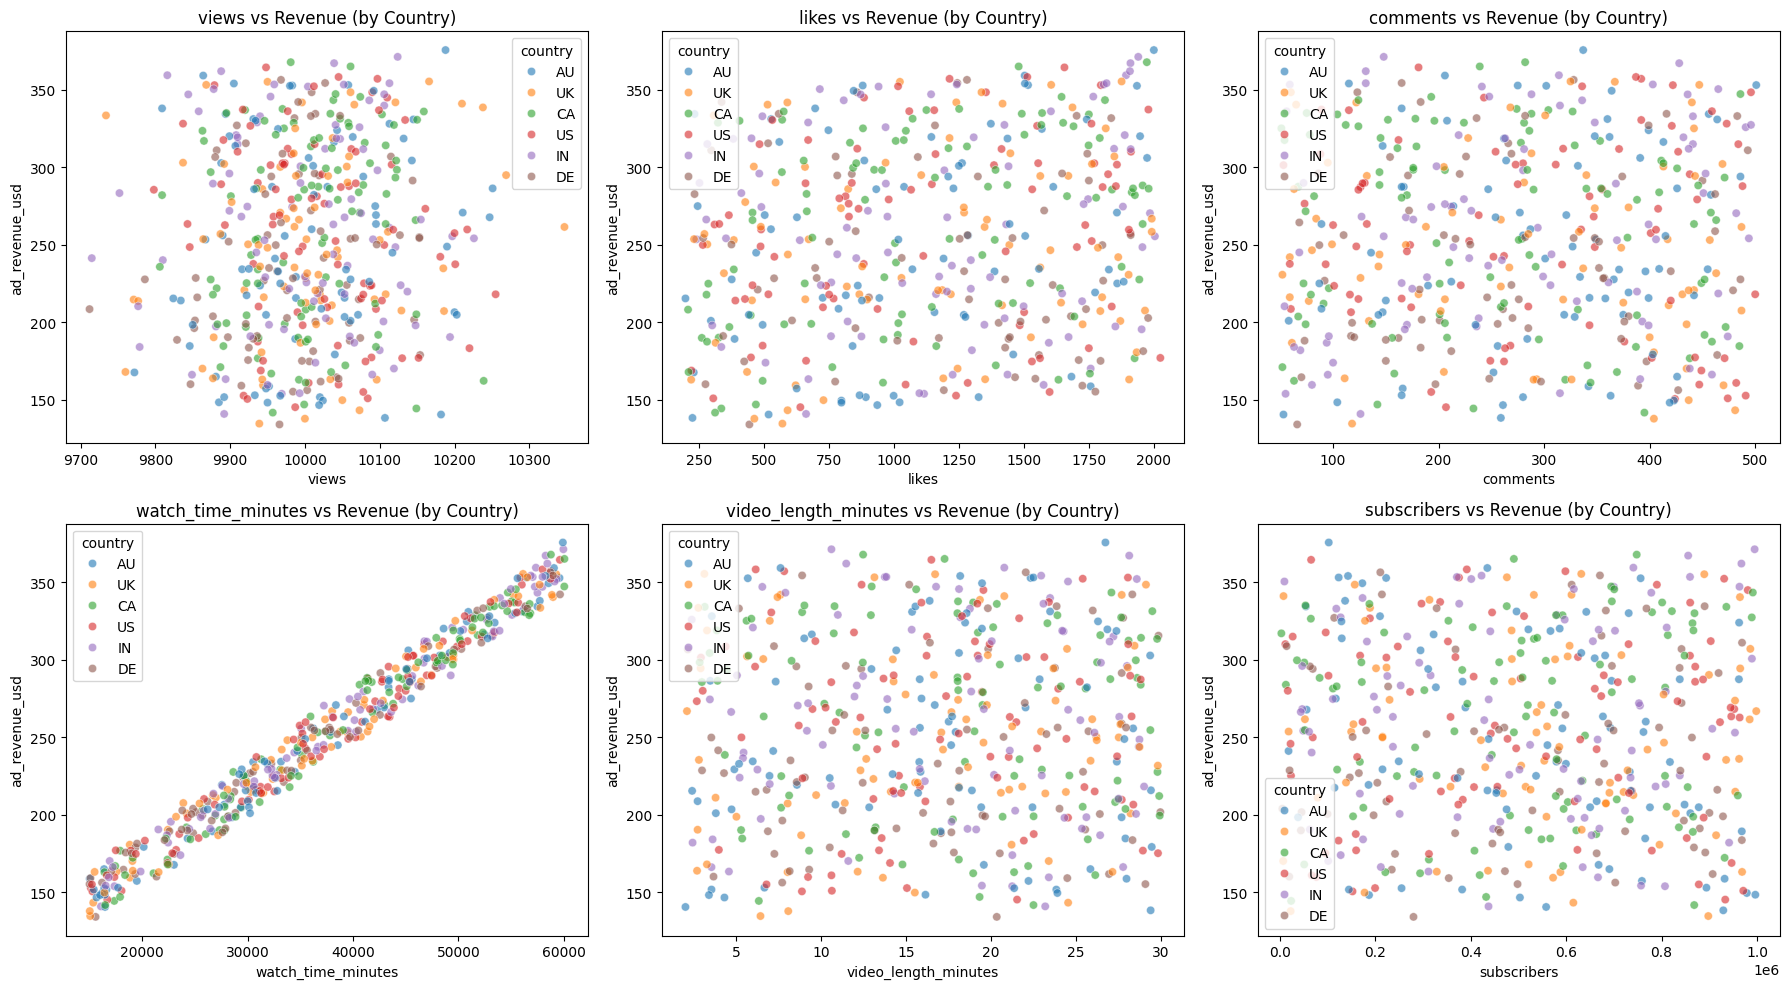

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Take random sample of 500 rows
df_sample = df.sample(n=500, random_state=42)

# numerical columns
num_cols = df_sample.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('ad_revenue_usd')

# grid size
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    
    sns.scatterplot(
        data=df_sample,
        x=col,
        y='ad_revenue_usd',
        hue='country',   # 👈 KEY CHANGE
        alpha=0.6
    )
    
    plt.title(f"{col} vs Revenue (by Country)")

plt.tight_layout()
plt.show()

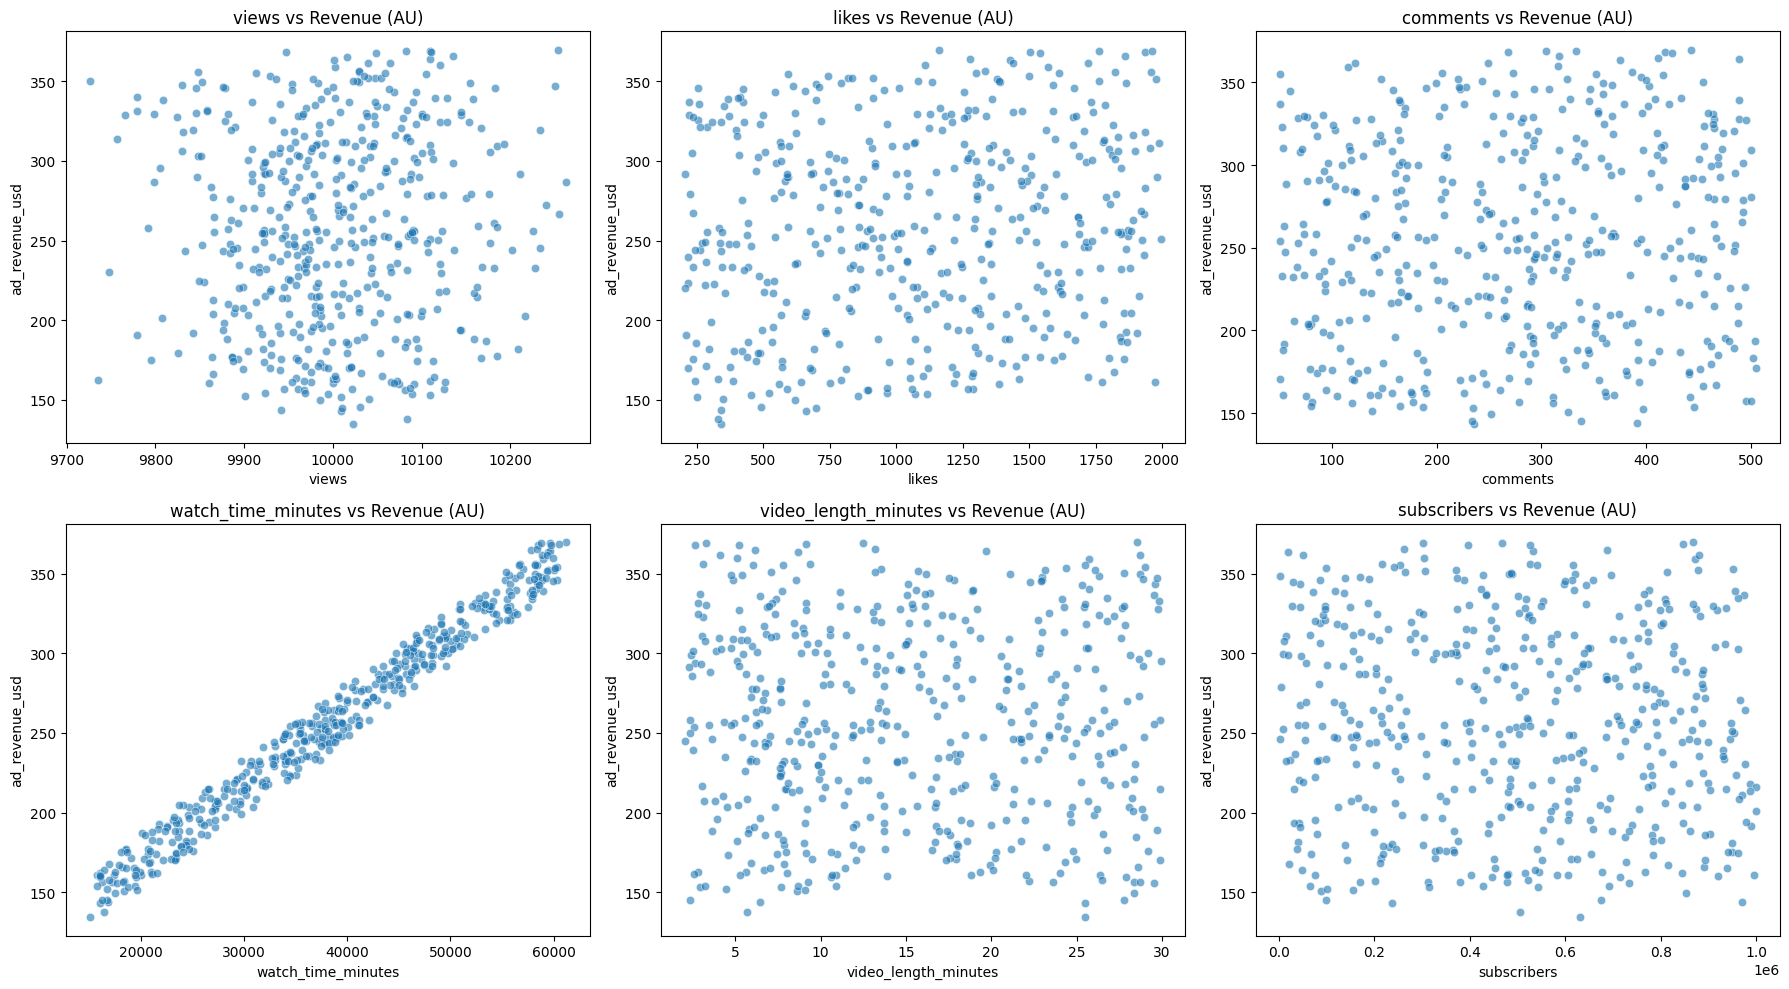

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# choose country
country_name = 'AU'   # change to 'IN', 'UK', etc.

# filter data
df_country = df[df['country'] == country_name].sample(n=500, random_state=42)

# numerical columns
num_cols = df_country.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('ad_revenue_usd')

# grid
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    
    sns.scatterplot(
        data=df_country,
        x=col,
        y='ad_revenue_usd',
        alpha=0.6
    )
    
    plt.title(f"{col} vs Revenue ({country_name})")

plt.tight_layout()
plt.show()

In [54]:
df['video_id'].value_counts().head()

video_id
vid_3033    46
vid_1725    42
vid_4483    42
vid_988     41
vid_2429    40
Name: count, dtype: int64

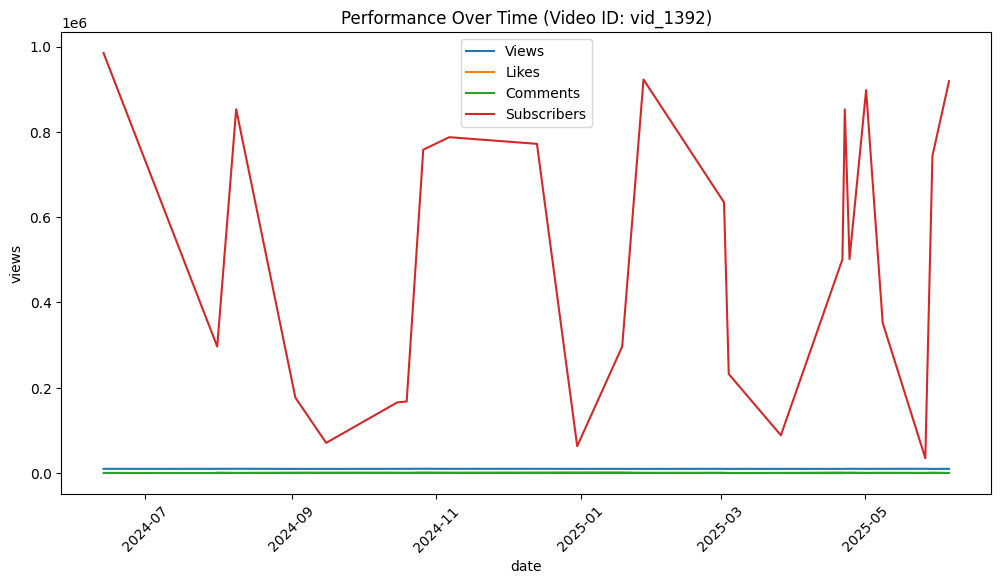

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# choose video
video_id = df['video_id'].iloc[100]

# filter that video
video_df = df[df['video_id'] == video_id].sort_values('date')

# plot multiple metrics
plt.figure(figsize=(12,6))

sns.lineplot(data=video_df, x='date', y='views', label='Views')
sns.lineplot(data=video_df, x='date', y='likes', label='Likes')
sns.lineplot(data=video_df, x='date', y='comments', label='Comments')
sns.lineplot(data=video_df, x='date', y='subscribers', label='Subscribers')

plt.title(f"Performance Over Time (Video ID: {video_id})")
plt.xticks(rotation=45)
plt.legend()
plt.show()

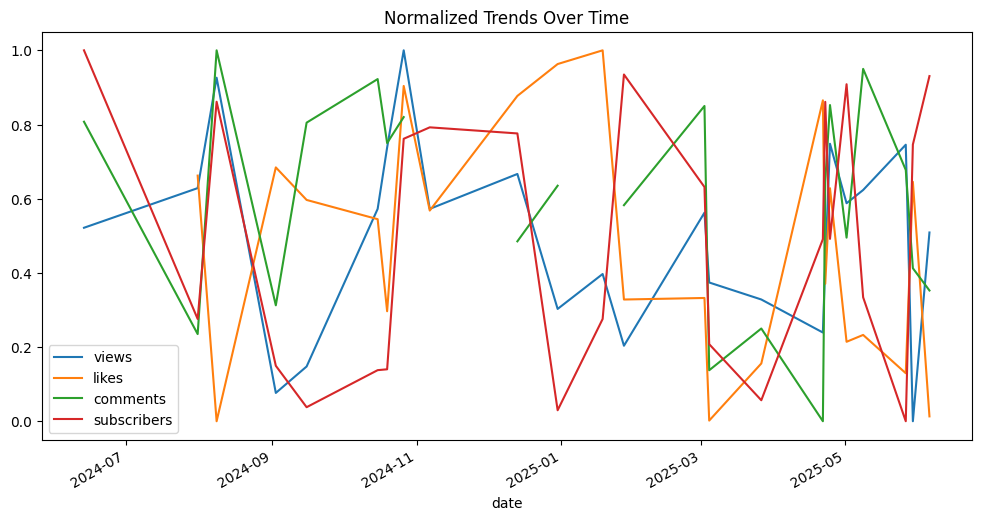

In [58]:
normalized_df = video_df[['views','likes','comments','subscribers']]

normalized_df = (normalized_df - normalized_df.min()) / (normalized_df.max() - normalized_df.min())

normalized_df['date'] = video_df['date']

normalized_df.set_index('date').plot(figsize=(12,6))
plt.title("Normalized Trends Over Time")
plt.show()